<a href="https://colab.research.google.com/github/madanjha/Machine-Learning/blob/main/BaggingAndBoosting06Sept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

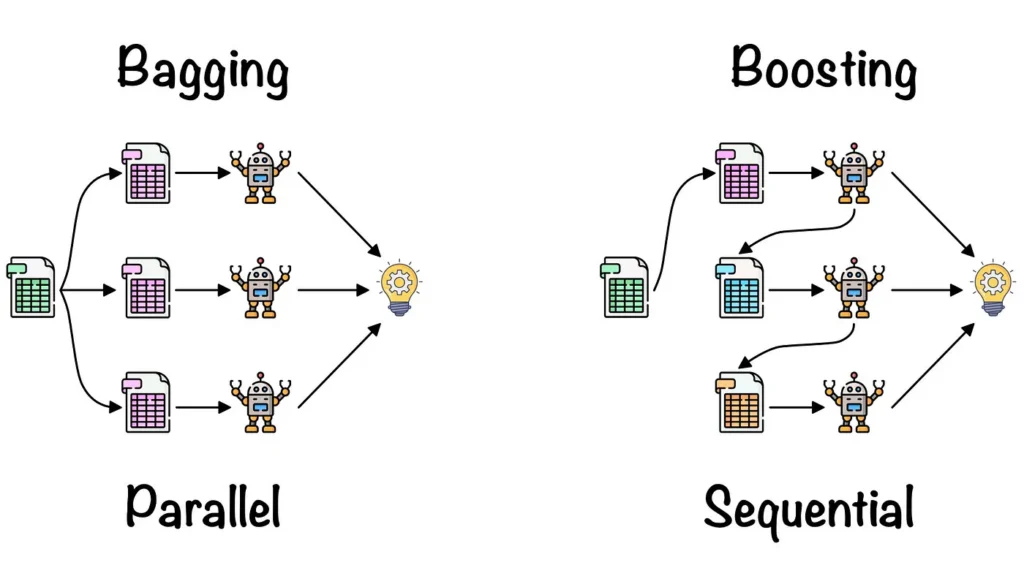

##**Bagging (Bootstrap Aggregation)**
Train many models spereatly on random parts of the data, then we combine their answer

**Steps**
* We will randomly pick different subset of our dataset (With replacement - Meaning some data points can appear more than once in a subset)
* You train a model on each subset of your dataset independently (like multiple students prepare alone)
* At the end, we will combine their results:
    * For Classification - The Vote for the majoirty will be our answer
    * For Regression - The average of their predictions

**In Real World** `Random Forest` is just a bunch of `decision Tree` trained using bagging

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# mod = RandomForestClassifier(n_estimators=100, oob_score=True)
# here the oob_score is basically out of bag score which cross validify the Training set

##**Boosting**
If we train models one after another, and each new model will focus on fixing the mistakes(erros) of the previous one.

**Steps**
* Start with a simple model ('Weak Learner')
* We will see where it makes mistake
* Give more importance (Weights) to the wrongly predicted data points
* Train the next model, which focuses more on those mistakes.
* We will Keep repeating this process, and in the end, we will combine all models (Weighted sum or Vote)

**Example**

Imagine you are a teacher helping a student pass a test
* First day: You teach all topics equaly
* Student makes mistakes in any one topic (Chemistry)
* Next Day: You will foucs more on Chemistry
* Stundent is still struggling with Maths -> Focus on the next weak feature
* Over time, the student gets better because you keep fixing the weak spots.

Real life: `AdaBoost`, `Gradient Boost`, `XGBoost` -> all are boosting methods

###**AdaBoost (Adaptive Boosting)**
* We train weak models (usually small decision trees) one by one
* After each models, increase the weight of the data points that were predicted wrong, so the next model focuses on them more.
* At the end, we just combine all models with weight based on how good they were

**Steps**

Let's imagine
* We have 4 points to classify as Red or Blue
* We use weak learners (like small decision tree -> 1 split decision)
* Initaly the weight for all points  = equal

**Step 1**

We give each data point a weight:

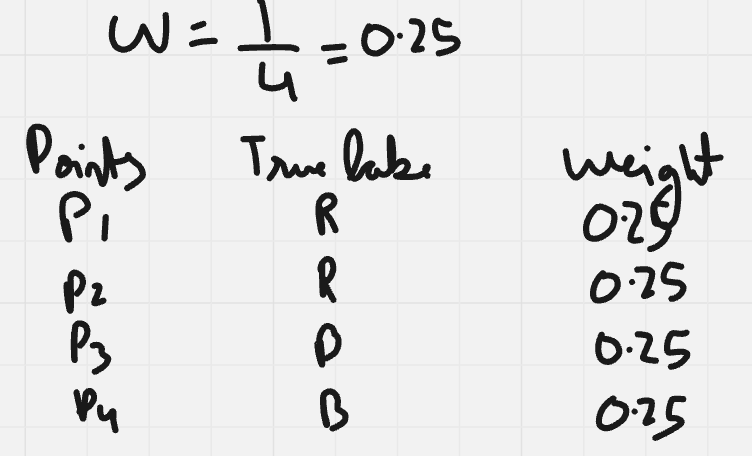

**Step 2**

Train First weak model

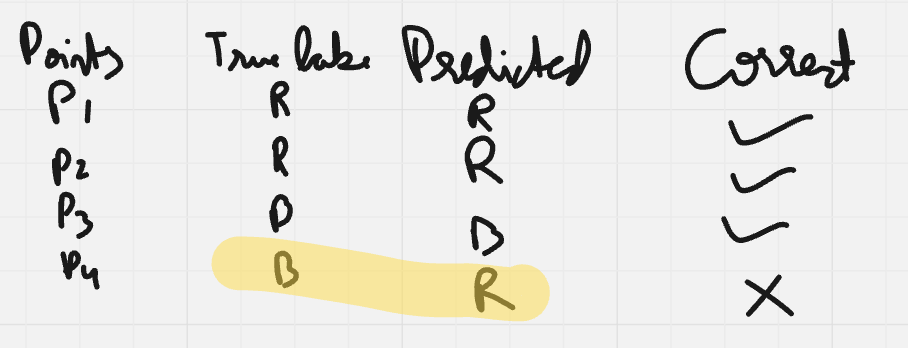

**Step 3**

Model Weight (Alpha)

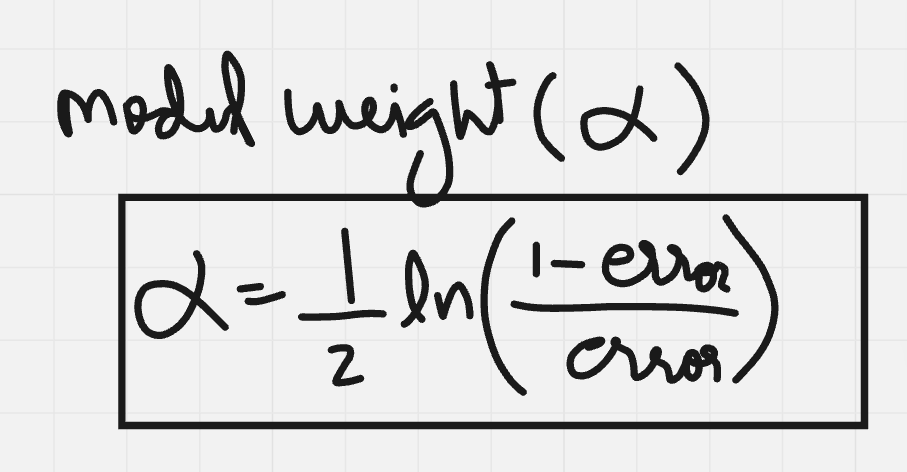

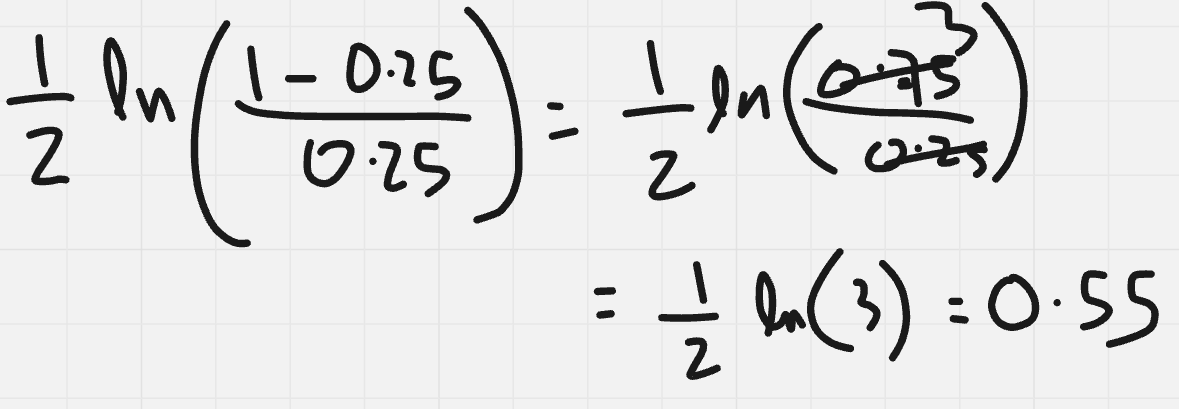

In [ ]:
np.log(3)/2 # =0.55

np.float64(0.5493061443340549)

**Step 4**

Update the weights

for `wrong predictions`:
  * `New Weight = Old Weight x e^a`

For `Correct Predictions`:
  * `New Weight = Old Weight x e^(-a)`

---

* Wrong weight ones get Heavier (harder points).

* Right ones get lighter (Easy points)

We then normalize the weights so that they sum to 1

**Step 5**

Next Weak model

We train model 2 on the new weights - it will focus more on the previously  wrong points (Repeat)

**Step 6**

Final Prediction

We combine all model's prediction, weighted by their alpha(a) better models get more to say


In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

**Let's Create a sample data**

In [ ]:
X = np.array([
    [1,2],
    [2,1],
    [2,3],
    [3,2],
    [3,3],
    [4,4]
])
X

array([[1, 2],
       [2, 1],
       [2, 3],
       [3, 2],
       [3, 3],
       [4, 4]])

In [ ]:
y = np.array([0,0,1,1,1,0])
y

array([0, 0, 1, 1, 1, 0])

**Let's make a weak learner (Base Model)**

In [ ]:
ModelDT = DecisionTreeClassifier(max_depth=1) # Weak learner

**Now let's Build Adaboost model**

In [ ]:
model = AdaBoostClassifier(
    estimator= ModelDT, # weak learner
    n_estimators= 5,
    learning_rate = 1.0,
    random_state = 42
)

**Training the model**

In [ ]:
model.fit(X,y)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=5, random_state=42)

**Predictions**

In [ ]:
preds = model.predict(X)

In [ ]:
preds

array([0, 0, 1, 1, 1, 0])

In [ ]:
model.feature_importances_ # Features importance probabilty x1 x2

array([0.55300711, 0.44699289])

In [ ]:
model.estimator_weights_ # Here these are the alpha values

array([0.69314718, 0.51082562, 0.84729786, 0.80234647, 1.05314991])

In [ ]:
model.estimator_errors_

array([0.33333333, 0.375     , 0.3       , 0.30952381, 0.25862069])

In [ ]:
preds

array([0, 0, 1, 1, 1, 0])

In [ ]:
model.predict_proba(X)

array([[0.61510376, 0.38489624],
       [0.57712635, 0.42287365],
       [0.40162448, 0.59837552],
       [0.40162448, 0.59837552],
       [0.40162448, 0.59837552],
       [0.60415141, 0.39584859]])

**Let's Check on Dataset**

**Import**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

**Read Data**

In [ ]:
df = pd.read_csv('/content/census-income .csv')

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


**Find out the number of unique values in native country and occupation column**

In [ ]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'annual_income'],
      dtype='object')

In [ ]:
df['native-country'].nunique()

42

In [ ]:
df['occupation'].nunique()

15

In [ ]:
df['occupation'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', '?', 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [ ]:
df[df['occupation'] == '?']

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
27,54,?,180211,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
61,32,?,293936,7th-8th,4,Married-spouse-absent,?,Not-in-family,White,Male,0,0,40,?,<=50K
69,25,?,200681,Some-college,10,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K
77,67,?,212759,10th,6,Married-civ-spouse,?,Husband,White,Male,0,0,2,United-States,<=50K
106,17,?,304873,10th,6,Never-married,?,Own-child,White,Female,34095,0,32,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32530,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32531,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32539,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32541,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [ ]:
df.replace('?', np.nan, inplace= True)
# df = df.replace('?',np.nan)

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df['occupation'].unique()

array(['Adm-clerical', 'Exec-managerial', 'Handlers-cleaners',
       'Prof-specialty', 'Other-service', 'Sales', 'Craft-repair',
       'Transport-moving', 'Farming-fishing', 'Machine-op-inspct',
       'Tech-support', nan, 'Protective-serv', 'Armed-Forces',
       'Priv-house-serv'], dtype=object)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


**Shape inspection**

In [ ]:
a = df.shape
print(f'Rows : {a[0]} and Columns: {a[1]}')

Rows : 32561 and Columns: 15


In [ ]:
df.dropna(inplace= True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education-num   30162 non-null  int64 
 5   marital-status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital-gain    30162 non-null  int64 
 11  capital-loss    30162 non-null  int64 
 12  hours-per-week  30162 non-null  int64 
 13  native-country  30162 non-null  object
 14  annual_income   30162 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.duplicated().sum()

np.int64(23)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

**We will Check for outliers in this data**

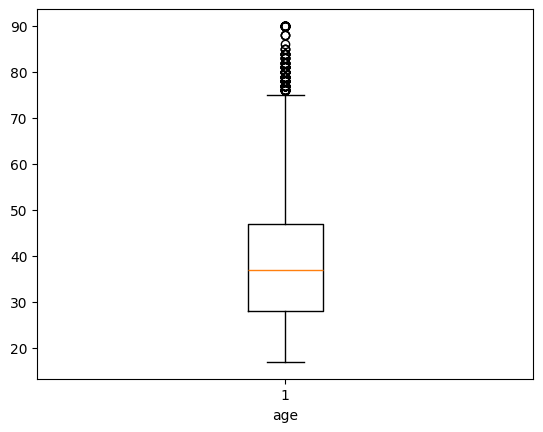

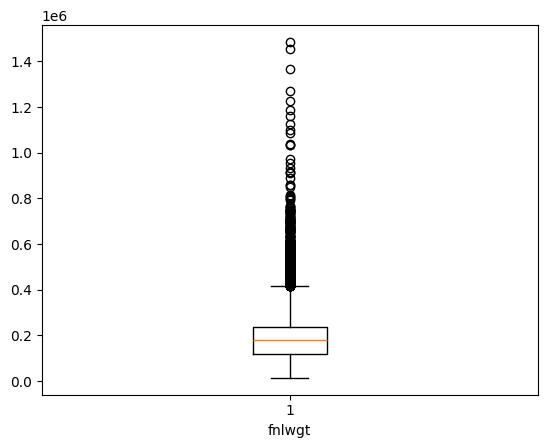

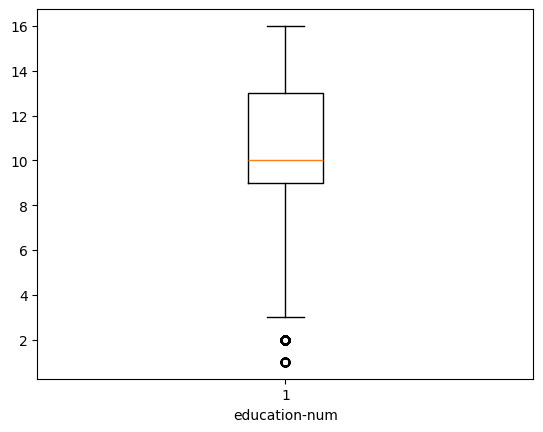

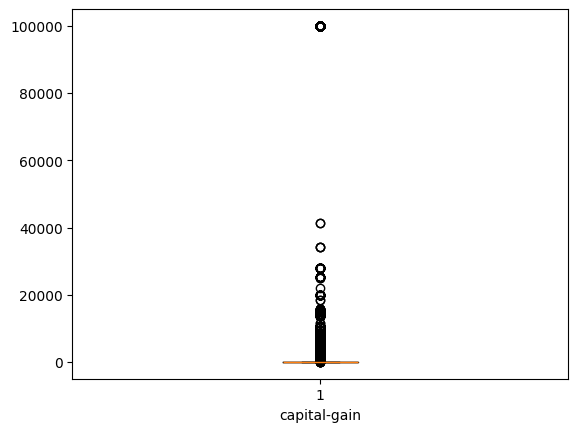

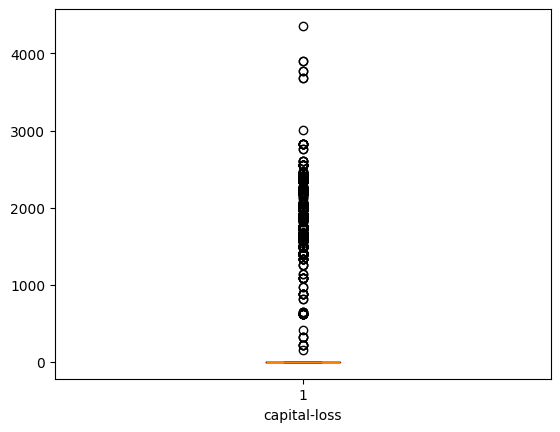

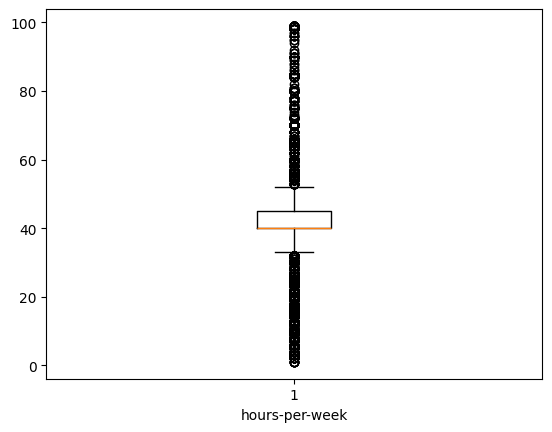

In [ ]:
for x in df.columns:
  if df[x].dtype != 'object':
    plt.boxplot(df[x])
    plt.xlabel(x)
    plt.show()

In [ ]:
out_list = ['age','hours-per-week', 'fnlwgt']

In [ ]:
for x in out_list:
  Q1 = df[x].quantile(0.25)
  Q3 = df[x].quantile(0.75)
  IQR = Q3 - Q1

  lb = Q1 - 1.5*IQR
  ub = Q3 + 1.5 * IQR

  df = df[(df[x]>= lb) & (df[x]<=ub)]


In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21440 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             21440 non-null  int64 
 1   workclass       21440 non-null  object
 2   fnlwgt          21440 non-null  int64 
 3   education       21440 non-null  object
 4   education-num   21440 non-null  int64 
 5   marital-status  21440 non-null  object
 6   occupation      21440 non-null  object
 7   relationship    21440 non-null  object
 8   race            21440 non-null  object
 9   sex             21440 non-null  object
 10  capital-gain    21440 non-null  int64 
 11  capital-loss    21440 non-null  int64 
 12  hours-per-week  21440 non-null  int64 
 13  native-country  21440 non-null  object
 14  annual_income   21440 non-null  object
dtypes: int64(6), object(9)
memory usage: 2.6+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
cat_col = []
for i in df.columns:
  if (df[i].dtype == 'object'):
    cat_col.append(i)

In [ ]:
cat_col

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country',
 'annual_income']

In [ ]:
le = LabelEncoder()
labelMap = {} # Here we will see what value has been changed to what
for x in cat_col:
  df[x] = le.fit_transform(df[x])
  labelMap[x] = dict(zip(le.classes_, le.transform(le.classes_))) # We will typecast it into dict
  print(f'Mapped for {x}:{labelMap[x]} ')

Mapped for workclass:{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6)} 
Mapped for education:{'10th': np.int64(0), '11th': np.int64(1), '12th': np.int64(2), '1st-4th': np.int64(3), '5th-6th': np.int64(4), '7th-8th': np.int64(5), '9th': np.int64(6), 'Assoc-acdm': np.int64(7), 'Assoc-voc': np.int64(8), 'Bachelors': np.int64(9), 'Doctorate': np.int64(10), 'HS-grad': np.int64(11), 'Masters': np.int64(12), 'Preschool': np.int64(13), 'Prof-school': np.int64(14), 'Some-college': np.int64(15)} 
Mapped for marital-status:{'Divorced': np.int64(0), 'Married-AF-spouse': np.int64(1), 'Married-civ-spouse': np.int64(2), 'Married-spouse-absent': np.int64(3), 'Never-married': np.int64(4), 'Separated': np.int64(5), 'Widowed': np.int64(6)} 
Mapped for occupation:{'Adm-clerical': np.int64(0), 'Armed-Forces': np.int64(1), 'Craft-repair': np.int64(2), 'Exec-managerial': np.int

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38,0
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,2,338409,9,13,2,9,5,2,0,0,0,40,4,0
5,37,2,284582,12,14,2,3,5,4,0,0,0,40,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,22,2,310152,15,10,4,10,1,4,1,0,0,40,38,0
32556,27,2,257302,7,12,2,12,5,4,0,0,0,38,38,0
32557,40,2,154374,11,9,2,6,0,4,1,0,0,40,38,1
32558,58,2,151910,11,9,6,0,4,4,0,0,0,40,38,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
x = df.iloc[:,:-1]
y = df['annual_income']
x


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,5,77516,9,13,4,0,1,4,1,2174,0,40,38
2,38,2,215646,11,9,0,5,1,4,1,0,0,40,38
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38
4,28,2,338409,9,13,2,9,5,2,0,0,0,40,4
5,37,2,284582,12,14,2,3,5,4,0,0,0,40,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,22,2,310152,15,10,4,10,1,4,1,0,0,40,38
32556,27,2,257302,7,12,2,12,5,4,0,0,0,38,38
32557,40,2,154374,11,9,2,6,0,4,1,0,0,40,38
32558,58,2,151910,11,9,6,0,4,4,0,0,0,40,38


In [ ]:
y

,annual_income
0,0
2,0
3,0
4,0
5,0
...,...
32555,0
32556,0
32557,1
32558,0


In [ ]:
x_train, x_test, y_train , y_test = train_test_split(x,y,test_size=0.3, random_state=42)

In [ ]:
x_train.shape

(15008, 14)

In [ ]:
x_test.shape

(6432, 14)

In [ ]:
y_train.shape

(15008,)

In [ ]:
lrModel = LogisticRegression()
lrModel.fit(x_train, y_train)

LogisticRegression()

In [ ]:
lrPred = lrModel.predict(x_test)

In [ ]:
lrPred

array([1, 0, 0, ..., 0, 0, 0])

In [ ]:
accuracy_score(lrPred,y_test)

0.7840485074626866

In [ ]:
dtModel = DecisionTreeClassifier()
dtModel.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
dtPred = dtModel.predict(x_test)

In [ ]:
accuracy_score(dtPred,y_test)

0.7935323383084577

In [ ]:
adaModel = AdaBoostClassifier(n_estimators = 50) # Selecting 50 weak models (50 decision trees)

In [ ]:
adaModel.fit(x_train,y_train)

AdaBoostClassifier()

In [ ]:
adaPred = adaModel.predict(x_test)

In [ ]:
adaPred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
accuracy_score(adaPred,y_test) # Better result than our decision tree and logistic regression

0.8387748756218906

**We will use some parameters to check can we optimze the model more better**